Step 1 - Import Required Libraries and Dependencies.
         Load Python packages for data manipulation, visualization,            preprocessing, modeling training, and evaluation.

In [1]:
# Step 1: Data Loading & Inspection

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)


Step 2 - Load and Inspect Dataset Files.
         Import the training, testing, and submission datasets and              verify that the data has been loaded correctly.

In [2]:
# Step 2: Load and Inspect Dataset Files

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

print(train.shape)
print(test.shape)

train.head()


(20758, 18)
(13840, 17)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


Step3 -  Exploratory Data Analysis (EDA) and Dataset Overview.
         Examine data structure, feature types, record counts, missing          values, and descriptive statistics to understand the dataset.

In [3]:
# Step 3: Exploratory Data Analysis (EDA) and Dataset Overview

train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


Step 4 - Correlation Analysis of Numerical Features.
         Analyze relationships between numerical variables using a              correlation heatmap to identify feature interactions and              potential predictors..

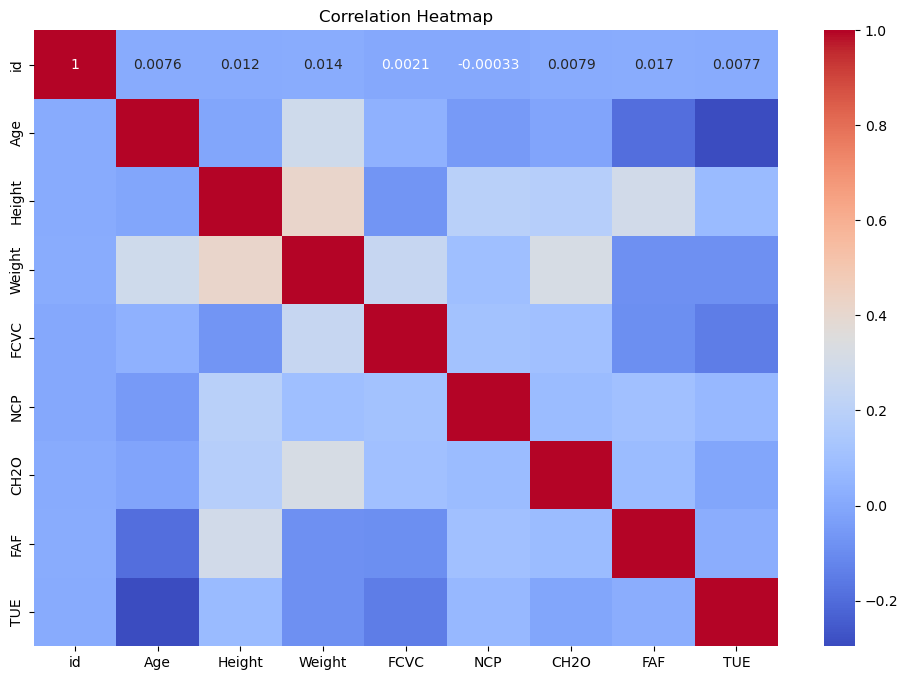

In [4]:
# Step 4 Correlation Analysis of Numerical Features

plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True),
cmap='coolwarm',
annot=True)
plt.title("Correlation Heatmap")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 3_RANDOM FOREST SUBMISSION/reports/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

Step 5 - Feature Distribution Analysis.
         Visualize the distribution of numerical variables using                histograms to detect patterns, skewness, and potential                outliers..

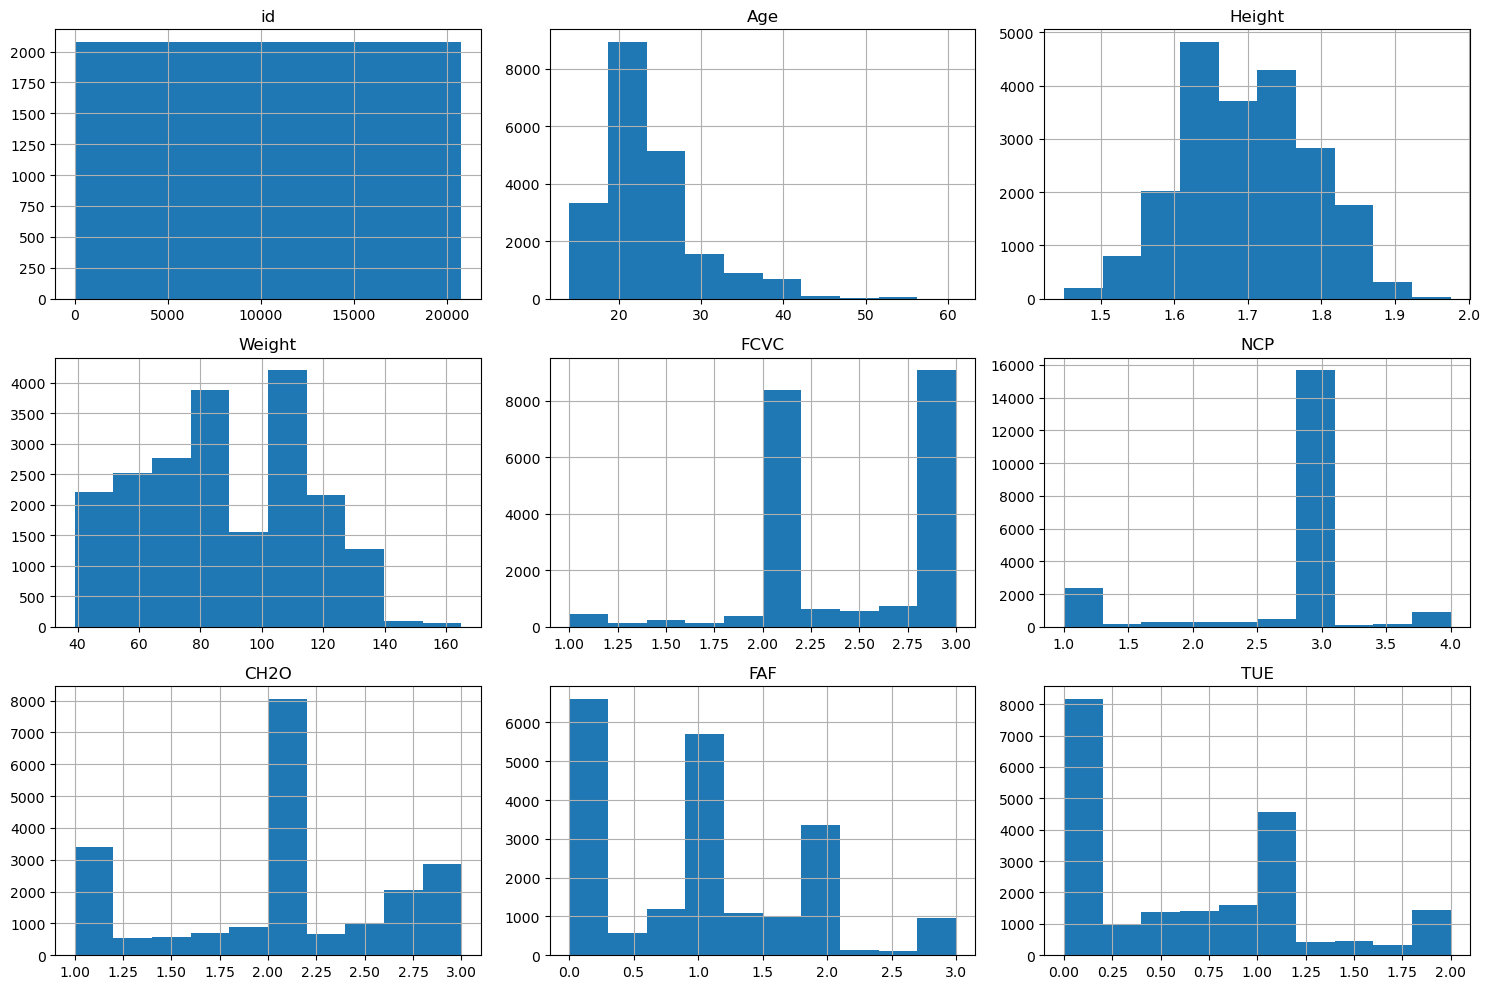

In [5]:
# Step 5: Feature Distribution Analysis

train.hist(figsize=(15,10))
plt.tight_layout()

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 3_RANDOM FOREST SUBMISSION/reports/figures/feature_distributions.png", dpi=300, bbox_inches="tight")

plt.show()

Step 6 -  Target Variable Distribution Analysis.
          Examine the class balance of obesity categories to determine           whether class imbalance may affect model performance.

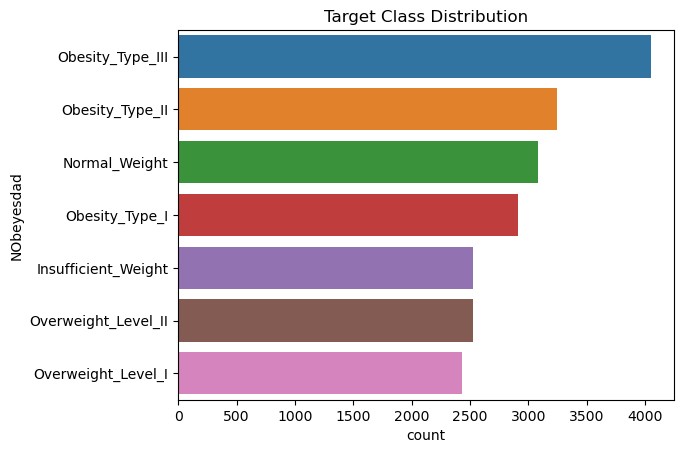

In [6]:
# Step 6: Target Variable Distribution Analysis

sns.countplot(
    y='NObeyesdad',
    data=train,
    order=train['NObeyesdad'].value_counts().index
)

plt.title("Target Class Distribution")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 3_RANDOM FOREST SUBMISSION/reports/figures/class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


Step 7 -  Categorical Feature Encoding and Data Preparation.
          Convert categorical variables into numerical values and               prepare feature matrices and target labels for machine                 learning..

In [7]:
# Step 7: Categorical Feature Encoding and Data Preparation

combined = pd.concat([train.drop("NObeyesdad", axis=1), test])

categorical_cols = combined.select_dtypes(include=["object"]).columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])
    encoders[col] = le

X_train_full = combined.iloc[:len(train)]
X_test = combined.iloc[len(train):]

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(train["NObeyesdad"])


Step 8 -  Train–Validation Data Splitting.
          Split the dataset into training and validation subsets to             enable unbiased model evaluation.

In [8]:
# Step 8: Train–Validation Data Splitting
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, 
    y, 
    test_size=0.2, 
    random_state=42
)


Step 9 - Random Forest Model Training.
         Build and train the Random Forest classifier using the                training data and selected hyperparameters.

In [9]:
# Step 9: Random Forest Model Training

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)




RandomForestClassifier(max_depth=15, n_estimators=500, n_jobs=-1,
                       random_state=42)

Step 10 - Model Performance Evaluation.
          Generate predictions on the validation set and calculate               classification accuracy.

In [10]:
# Step 10: Model Performance Evaluation

rf_preds = rf_model.predict(X_valid)

print(accuracy_score(y_valid, rf_preds))


0.8973988439306358


Step 11 -  Confusion Matrix Performance Analysis.
           Evaluate classification results by visualizing correct and            incorrect predictions across obesity classes.


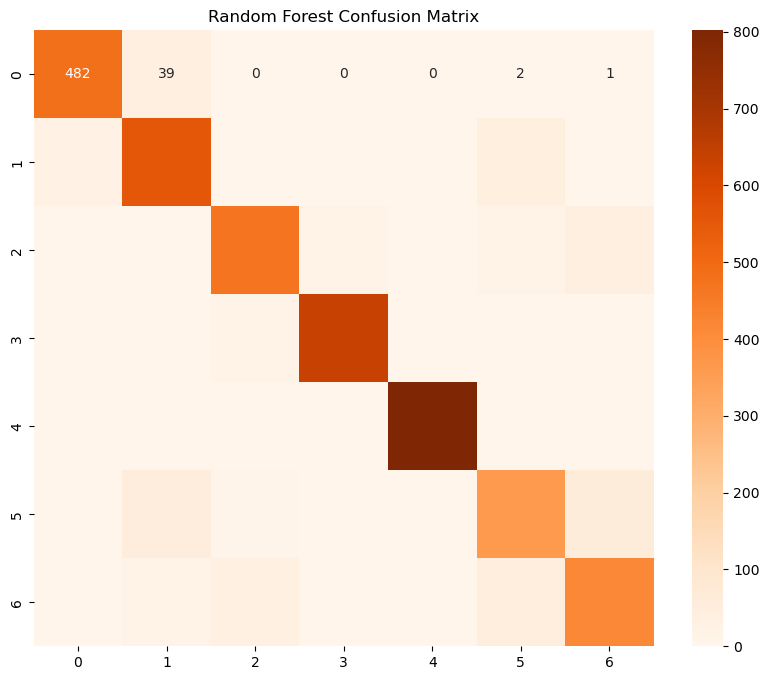

In [11]:
# Step 11: Confusion Matrix Performance Analysis

plt.figure(figsize=(10, 8))

sns.heatmap(
    confusion_matrix(y_valid, rf_preds),
    annot=True,
    cmap='Oranges',
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 3_RANDOM FOREST SUBMISSION/reports/figures/random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

Step 12 - Feature Importance Evaluation.
          Identify and rank the most influential features contributing           to Random Forest predictions.

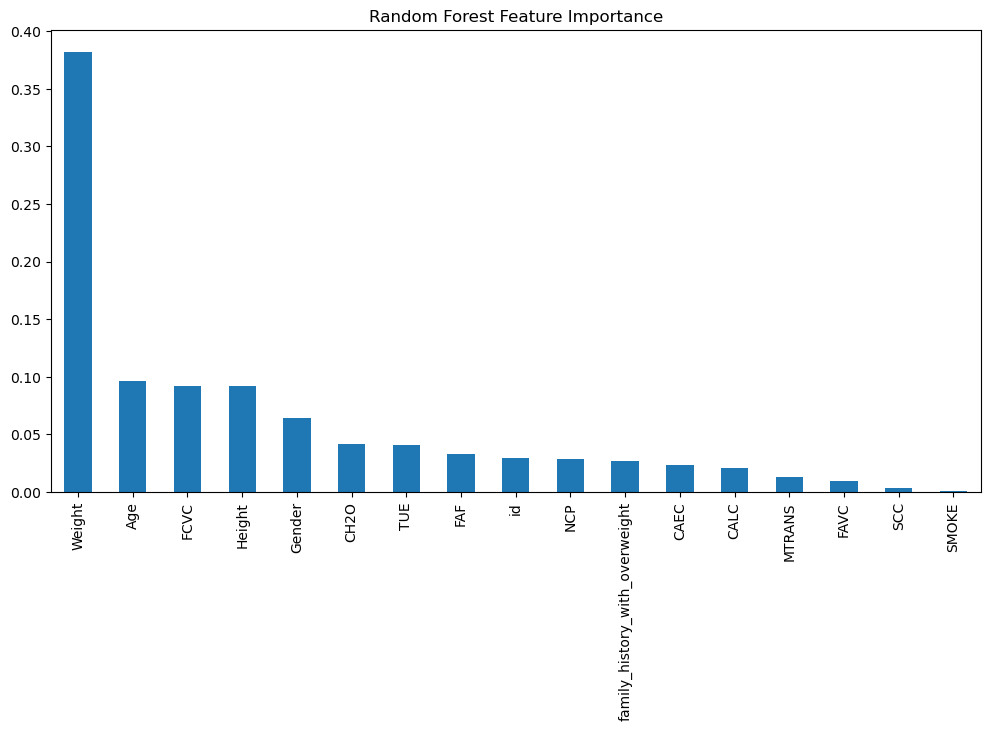

In [12]:
# Step 12: Feature Importance Evaluation

importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

importance_rf.sort_values(
    ascending=False
).head(20).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Random Forest Feature Importance")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 3_RANDOM FOREST SUBMISSION/reports/figures/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")


plt.show()

Step 13 - Top Predictive Feature Visualization.
          Visualize the behavior and distribution of the most                   important features across obesity categories using boxplots           and count plots.

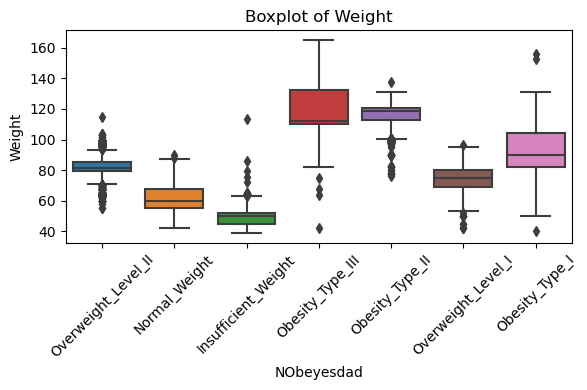

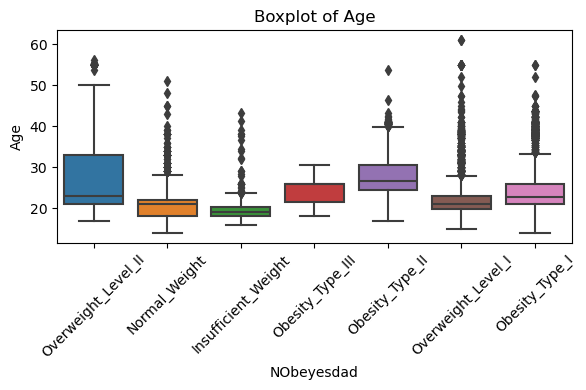

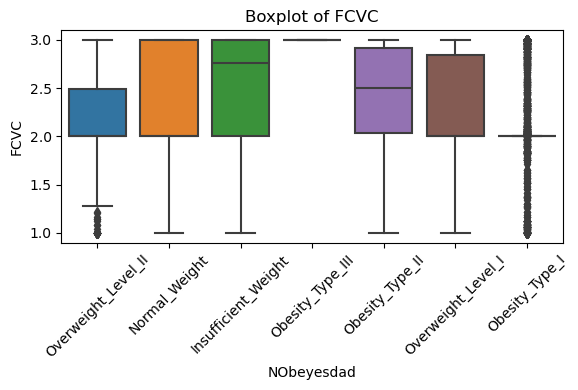

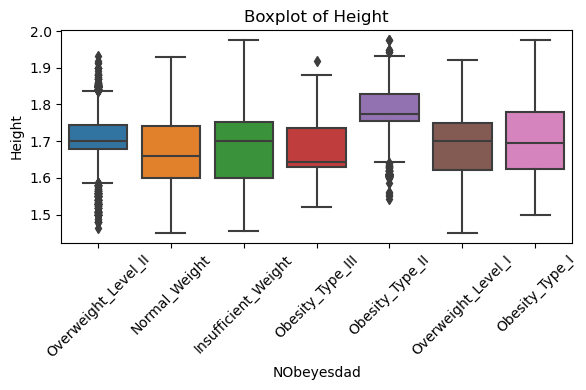

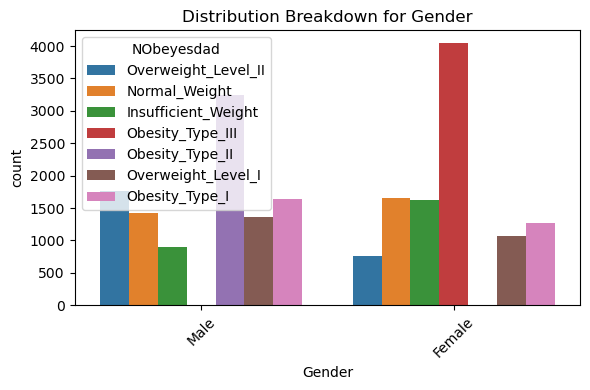

In [13]:
# Step 13 - Top Predictive Feature Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your data frame and top features first
plot_df = train
top_features = importance_rf.sort_values(ascending=False).head(5).index.tolist()

# 2. Run the loop to generate the plots
for feature in top_features:
    
    # Check if the feature is a numeric column (like Weight, Age, Height)
    if plot_df[feature].dtype in ['int64', 'float64']:
        # 1. Create a dedicated figure for the Boxplot
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=plot_df, x='NObeyesdad', y=feature)
        plt.title(f"Boxplot of {feature}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 3_RANDOM FOREST SUBMISSION/reports/figures/f_boxplot_of_feature.png", dpi=300, bbox_inches="tight")
        
        plt.show() 
        
    # Check if the feature is a categorical column (like Gender)
    else:
        # 2. Create a COMPLETELY SEPARATE figure for the side-by-side bar chart
        plt.figure(figsize=(6, 4))
        sns.countplot(data=plot_df, x=feature, hue='NObeyesdad')
        plt.title(f"Distribution Breakdown for {feature}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 3_RANDOM FOREST SUBMISSION/reports/figures/f_Distribution Breakdown.png", dpi=300, bbox_inches="tight")
        
        plt.show()


Step 14 -  Generate Kaggle Submission 3 File. 
           Produce predictions on the test dataset and export them as            a competition-ready submission file.

In [14]:
# Step 14: Generate Kaggle Submission File


rf_test_preds = rf_model.predict(X_test)

submission['NObeyesdad'] = target_encoder.inverse_transform(
    rf_test_preds
)

submission.to_csv(
    "submission_random_forest.csv",
    index=False
)
